In [4]:
import tensorflow as tf
import numpy as np
import json

In [5]:
data_path = "/content/train_spider.json"

In [6]:
with open(data_path, "r", encoding="utf-8") as f:
  data = json.load(f)
print("number of queries: ", len(data))
print(data[0])

number of queries:  7000
{'db_id': 'department_management', 'query': 'SELECT count(*) FROM head WHERE age  >  56', 'query_toks': ['SELECT', 'count', '(', '*', ')', 'FROM', 'head', 'WHERE', 'age', '>', '56'], 'query_toks_no_value': ['select', 'count', '(', '*', ')', 'from', 'head', 'where', 'age', '>', 'value'], 'question': 'How many heads of the departments are older than 56 ?', 'question_toks': ['How', 'many', 'heads', 'of', 'the', 'departments', 'are', 'older', 'than', '56', '?'], 'sql': {'from': {'table_units': [['table_unit', 1]], 'conds': []}, 'select': [False, [[3, [0, [0, 0, False], None]]]], 'where': [[False, 3, [0, [0, 10, False], None], 56.0, None]], 'groupBy': [], 'having': [], 'orderBy': [], 'limit': None, 'intersect': None, 'union': None, 'except': None}}


In [7]:
sql_sequences = [item["query_toks"] for item in data]
print("no. of sql sequences: ", len(sql_sequences))
print(sql_sequences[0])

no. of sql sequences:  7000
['SELECT', 'count', '(', '*', ')', 'FROM', 'head', 'WHERE', 'age', '>', '56']


In [8]:
# cleaning empty tokens.
clean_sequences = []
for seq in sql_sequences:
  cleaned_seq = [
      token for token in seq if token!=""
  ]
  clean_sequences.append(cleaned_seq)

In [9]:
# checking that no empty tokens exist.
empty_tokens = sum(
    1 for seq in clean_sequences for token in seq if token.strip() == ""
)
print("empty tokens: ", empty_tokens)

empty tokens:  0


In [10]:
# checking sequence lengths
lengths = [
    len(seq) for seq in clean_sequences
]
print("min length: ", min(lengths))
print("max length: ", max(lengths))
print("avg length: ", np.mean(lengths))

min length:  4
max length:  90
avg length:  18.493285714285715


In [11]:
MAX_LEN = 64
filtered_sequences = [
    seq for seq in clean_sequences if len(seq)<=MAX_LEN
]
print("Original queries:", len(clean_sequences))
print("Removed queries:", len(clean_sequences) - len(filtered_sequences))
print("Remaining queries:", len(filtered_sequences))

Original queries: 7000
Removed queries: 12
Remaining queries: 6988


In [12]:
filtered_lengths = [
    len(seq) for seq in filtered_sequences
]
print("min length: ", min(filtered_lengths))
print("max length: ", max(filtered_lengths))
print("avg length: ", np.mean(filtered_lengths))

min length:  4
max length:  61
avg length:  18.402261018889526


In [13]:
from tensorflow.keras.preprocessing.text import Tokenizer
tokenizer = Tokenizer(
    filters="", lower=False, oov_token="<UNK>"
)

In [14]:
tokenizer.fit_on_texts(clean_sequences)

In [15]:
word_index = tokenizer.word_index
print("vocabulary size: ", len(word_index))
print("First 20 tokens: ")
for token, idx in list(word_index.items())[:20]:
  print(f"{token:20}->{idx}")

vocabulary size:  4828
First 20 tokens: 
<UNK>               ->1
SELECT              ->2
FROM                ->3
=                   ->4
AS                  ->5
(                   ->6
)                   ->7
WHERE               ->8
JOIN                ->9
ON                  ->10
BY                  ->11
,                   ->12
T1                  ->13
T2                  ->14
*                   ->15
count               ->16
''                  ->17
``                  ->18
GROUP               ->19
ORDER               ->20


In [16]:
# converting tokens to IDs.
encoded_sequences = tokenizer.texts_to_sequences(filtered_sequences)
print("original: ")
print(filtered_sequences[0])
print("encoded: ")
print(encoded_sequences[0])

original: 
['SELECT', 'count', '(', '*', ')', 'FROM', 'head', 'WHERE', 'age', '>', '56']
encoded: 
[2, 16, 6, 15, 7, 3, 968, 8, 60, 25, 4307]


In [17]:
inputs = []
targets = []
for seq in encoded_sequences:
  inputs.append(seq[:-1])
  targets.append(seq[1:])

In [18]:
SEQ_LEN = MAX_LEN-1
# pad everything to 63.
from tensorflow.keras.utils import pad_sequences
inputs = pad_sequences(inputs, maxlen=SEQ_LEN, padding="post", truncating = "post", value=0)
targets = pad_sequences(targets, maxlen=SEQ_LEN, padding="post", truncating = "post", value=0)

In [19]:
from sklearn.model_selection import train_test_split

train_inputs, temp_inputs, train_targets, temp_targets = train_test_split(
    inputs,
    targets,
    test_size=0.30,
    random_state=42
)

val_inputs, test_inputs, val_targets, test_targets = train_test_split(
    temp_inputs,
    temp_targets,
    test_size=0.50,
    random_state=42
)

In [20]:
vocab_size = len(tokenizer.word_index) + 1
print("Vocabulary size:", vocab_size)

Vocabulary size: 4829


In [21]:
# creating tensorflow datasets.
BATCH_SIZE = 32
train_dataset = tf.data.Dataset.from_tensor_slices(
    (train_inputs, train_targets)
)
train_dataset = train_dataset.shuffle(
    len(train_inputs)
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices(
    (val_inputs, val_targets)
)
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices(
    (test_inputs, test_targets)
)

test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [22]:
from tensorflow.keras import layers
EMBED_DIM = 128
NUM_HEADS = 4
FF_DIM = 256

EMBED_DIM = 128: # Vector size used to represent each token in a continuous feature space

NUM_HEADS = 4: # Number of parallel attention mechanisms focusing on different patterns in the sequence

FF_DIM = 256: # Hidden layer size of the feed-forward network inside each Transformer block

In [25]:
from tensorflow import keras

In [35]:
inputs = keras.Input(shape=(SEQ_LEN,))

# Token embedding
x = layers.Embedding(
    vocab_size,
    EMBED_DIM
)(inputs)

# Positional embedding
positions = tf.range(
    start=0,
    limit=SEQ_LEN,
    delta=1
)

position_embedding = layers.Embedding(
    input_dim=SEQ_LEN,
    output_dim=EMBED_DIM
)(positions)

# Add token + position information
x = x + position_embedding

# Self-attention
attention_output = layers.MultiHeadAttention(
    num_heads=NUM_HEADS,
    key_dim=EMBED_DIM
)(
    x,
    x,
    use_causal_mask=True
)

# Residual + normalization
x = layers.Add()([x, attention_output])
x = layers.LayerNormalization()(x)

# Feed-forward network
ffn = layers.Dense(
    FF_DIM,
    activation="relu"
)(x)

ffn = layers.Dense(
    EMBED_DIM
)(ffn)

# Residual + normalization
x = layers.Add()([x, ffn])
x = layers.LayerNormalization()(x)

# Output
outputs = layers.Dense(
    vocab_size
)(x)

model = keras.Model(
    inputs,
    outputs
)

In [36]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 63)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 63, 128)   │    618,112 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 63, 128)   │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 63, 128)   │    263,808 │ add_4[0][0],      │
│ (MultiHeadAttentio… │                   │            │ add_4[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 63, 128)   │          0 │ add_4[0][0],      │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 63, 128)   │        256 │ add_5[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 63, 256)   │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 63, 128)   │     32,896 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 63, 128)   │          0 │ layer_normalizat… │
│                     │                   │            │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 63, 128)   │        256 │ add_6[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 63, 4829)  │    622,941 │ layer_normalizat… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,571,293 (5.99 MB)

 Trainable params: 1,571,293 (5.99 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.0003
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(
        from_logits=True
    ),
    metrics=["accuracy"]
)

In [38]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=100,
    callbacks=[early_stopping]
)

Epoch 1/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - accuracy: 0.7472 - loss: 3.2277 - val_accuracy: 0.8279 - val_loss: 1.3365
Epoch 2/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8433 - loss: 1.0715 - val_accuracy: 0.8508 - val_loss: 0.9626
Epoch 3/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8628 - loss: 0.8597 - val_accuracy: 0.8662 - val_loss: 0.8429
Epoch 4/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8742 - loss: 0.7662 - val_accuracy: 0.8727 - val_loss: 0.7824
Epoch 5/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8804 - loss: 0.7106 - val_accuracy: 0.8762 - val_loss: 0.7438
Epoch 6/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8847 - loss: 0.6701 - val_accuracy: 0.8796 - val_loss: 0.7134
Epoch 7/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8884 - loss: 0.6353 - val_accuracy: 0.8819 - val_loss: 0.6870
Epoch 8/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8916 - loss: 0.6031 -

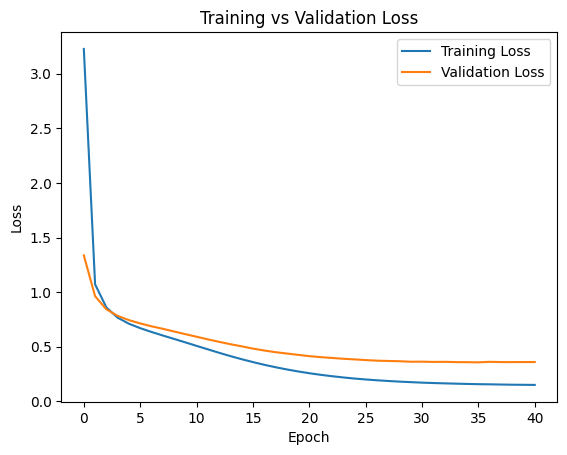

In [39]:
import matplotlib.pyplot as plt

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

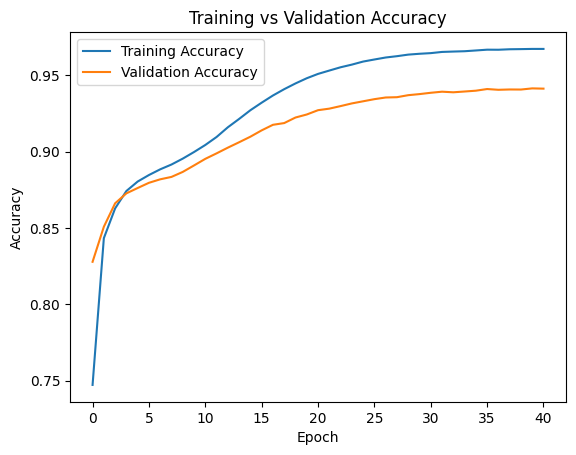

In [40]:
plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

In [41]:
test_loss, test_accuracy = model.evaluate(
    test_dataset
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9371 - loss: 0.3791
Test Loss: 0.3790701925754547
Test Accuracy: 0.9371283650398254


In [43]:
def decode_ids(sequence):
  return " ".join([tokenizer.index_word.get(i, "<UNK>") for i in sequence if i != 0])

sample_input, sample_target = next(
    iter(test_dataset)
)

sample_input = sample_input[0]
sample_target = sample_target[0]

actual_length = tf.math.count_nonzero(
    sample_input
).numpy()

context = sample_input[:actual_length]

# Pad the context to SEQ_LEN before passing to the model
context_padded = pad_sequences([context.numpy()], maxlen=SEQ_LEN, padding="post", truncating = "post", value=0)

prediction = model.predict(
    tf.expand_dims(context_padded[0], 0),
    verbose=0
)

next_token_id = tf.argmax(
    prediction[0, -1]
).numpy()

next_token = tokenizer.index_word.get(
    int(next_token_id),
    "<UNK>"
)

print("Context:")
print(decode_ids(context.numpy()))

print("\nPredicted next token:")
print(next_token)

Context:
SELECT T2.Shop_Name FROM stock AS T1 JOIN shop AS T2 ON T1.Shop_ID = T2.Shop_ID GROUP BY T1.Shop_ID ORDER BY COUNT ( * ) DESC LIMIT

Predicted next token:
<UNK>


In [44]:
model.save("/content/sql_transformer.keras")
print("Model saved successfully!")

Model saved successfully!


In [45]:
import pickle
with open("/content/sql_tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)
print("Tokenizer saved successfully!")

Tokenizer saved successfully!


In [46]:
config = {
    "MAX_LEN": MAX_LEN,
    "SEQ_LEN": SEQ_LEN,
    "vocab_size": vocab_size,
    "EMBED_DIM": EMBED_DIM,
    "NUM_HEADS": NUM_HEADS,
    "FF_DIM": FF_DIM,
    "BATCH_SIZE": BATCH_SIZE
}

with open("/content/sql_transformer_config.json", "w") as f:
    json.dump(config, f, indent=4)

print("Configuration saved successfully!")

Configuration saved successfully!


In [47]:
test_loss, test_accuracy = model.evaluate(
    test_dataset,
    verbose=0
)

results = {
    "test_loss": float(test_loss),
    "test_accuracy": float(test_accuracy),
    "best_val_loss": float(min(history.history["val_loss"])),
    "best_val_accuracy": float(max(history.history["val_accuracy"])),
    "epochs_trained": len(history.history["loss"])
}

with open("/content/transformer_results.json", "w") as f:
    json.dump(results, f, indent=4)

print(results)

{'test_loss': 0.3790701925754547, 'test_accuracy': 0.9371283650398254, 'best_val_loss': 0.35692062973976135, 'best_val_accuracy': 0.941430389881134, 'epochs_trained': 41}
